In [3]:
import pandas as pd

In [12]:
df= pd.read_csv("/home/akashmanna/dataset/inlp_project/clean_dataset.csv")

In [6]:
df= pd.read_csv("/home/akashmanna/dataset/inlp_project/full_dataset_with_sentiment.csv")

In [7]:
df.columns

Index(['date', 'text', 'sentiment', 'stock_symbol', 'open', 'high', 'low',
       'close', 'volume', 'running_max', 'running_min', 'positiveness',
       'negativeness'],
      dtype='object')

In [8]:
df

,date,text,sentiment,stock_symbol,open,high,low,close,volume,running_max,running_min,positiveness,negativeness
0,2018-01-02,new york (reuters) - european stocks closed lo...,positive,AAPL,39.812832,40.313533,39.602254,40.304173,102223600,41.460010,26.425788,0.039983,0.940610
1,2018-01-02,"january 2, 2018 / 1:06 pm / updated 2 hours ag...",neutral,AAPL,39.812832,40.313533,39.602254,40.304173,102223600,41.460010,26.425788,0.010289,0.962002
2,2018-01-02,"january 2, 2018 / 4:54 am / updated 12 minutes...",negative,AAPL,39.812832,40.313533,39.602254,40.304173,102223600,41.460010,26.425788,0.020051,0.678777
3,2018-01-02,"published: jan 2, 2018 8:32 a.m. et share uc b...",positive,AAPL,39.812832,40.313533,39.602254,40.304173,102223600,41.460010,26.425788,0.716375,0.018697
4,2018-01-02,"january 2, 2018 / 12:35 am / updated 4 minutes...",positive,AAPL,39.812832,40.313533,39.602254,40.304173,102223600,41.460010,26.425788,0.049773,0.936008
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74704,2023-06-30,april 5 (reuters) - abbvie inc on thursday sai...,negative,TSLA,260.600006,264.450012,259.890015,261.769989,112620800,414.496674,11.799333,0.025306,0.953451
74705,2023-06-30,(reuters) - abbvie inc on thursday said it sig...,negative,TSLA,260.600006,264.450012,259.890015,261.769989,112620800,414.496674,11.799333,0.684478,0.209736
74706,2023-09-01,"newport beach, calif.--(business wire)-- willi...",negative,TSLA,257.260010,259.079987,242.009995,245.009995,132541600,414.496674,11.799333,0.019556,0.033344
74707,2024-03-15,los angeles--(business wire)-- herbalife ltd. ...,negative,TSLA,163.160004,165.179993,160.759995,163.570007,97146800,414.496674,11.799333,0.024434,0.021974


In [10]:
df.columns = df.columns.get_level_values(0)

In [11]:
df

Price,Close,High,Low,Open,Volume,running_max,running_min
Date,,,,,,,
2024-01-02,183.731323,186.502538,181.999316,185.225793,82488700,186.502538,181.999316
2024-01-03,182.355606,183.968852,181.544030,182.325916,58414500,186.502538,181.544030
2024-01-04,180.039642,181.207503,179.020234,180.277165,71983600,186.502538,179.020234
2024-01-05,179.317139,180.880895,178.317529,180.118823,62379700,186.502538,178.317529
2024-01-08,183.652145,183.691743,179.633891,180.217821,59144500,186.502538,178.317529
2024-01-09,183.236435,183.246327,180.851210,182.028977,42841800,186.502538,178.317529
2024-01-10,184.275650,184.483482,182.028985,182.454572,46792900,186.502538,178.317529
2024-01-11,183.681839,185.126835,181.732092,184.622068,49128400,186.502538,178.317529
2024-01-12,184.008438,184.820014,183.285948,184.146998,40477800,186.502538,178.317529


In [3]:
import yfinance as yf

df = yf.download("AAPL", start="2024-01-01", end="2024-03-01")
df = df.sort_index()

df["running_max"] = df["High"].cummax()   # highest High seen so far
df["running_min"] = df["Low"].cummin()    # lowest Low seen so far

print(df[["Open", "High", "Low", "Close", "Volume", "running_max", "running_min"]])

[*********************100%***********************]  1 of 1 completed

Price             Open        High         Low       Close     Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL   
Date                                                                    
2024-01-02  185.225793  186.502538  181.999316  183.731323   82488700   
2024-01-03  182.325916  183.968852  181.544030  182.355606   58414500   
2024-01-04  180.277165  181.207503  179.020234  180.039642   71983600   
2024-01-05  180.118823  180.880895  178.317529  179.317139   62379700   
2024-01-08  180.217821  183.691743  179.633891  183.652145   59144500   
2024-01-09  182.028977  183.246327  180.851210  183.236435   42841800   
2024-01-10  182.454572  184.483482  182.028985  184.275650   46792900   
2024-01-11  184.622068  185.126835  181.732092  183.681839   49128400   
2024-01-12  184.146998  184.820014  183.285948  184.008438   40477800   
2024-01-16  180.287087  182.365486  179.069722  181.741974   65603000   
2024-01-17  179.406236  181.049157  178.446208  180

## Getting running max and min

In [4]:
"""
stock_features.py — Fetch running_max and running_min for a stock on a given date.

Usage:
    from datasets.stock_features import get_running_stats

    result = get_running_stats("AAPL", "2024-03-15")
    print(result)
    # {'ticker': 'AAPL', 'date': '2024-03-15',
    #  'running_max': 182.34, 'running_min': 124.17}
"""

import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta


def get_running_stats(
    ticker: str,
    date: str,
    lookback_days: int = 365,
) -> dict:
    """
    Return the running max and running min of a stock up to (and including) a given date.

    Running max = highest High price seen from `lookback_days` before `date` up to `date`.
    Running min = lowest  Low  price seen from `lookback_days` before `date` up to `date`.

    Parameters
    ----------
    ticker       : str   — Stock ticker symbol, e.g. "AAPL", "TSLA", "GOOGL"
    date         : str   — Target date in "YYYY-MM-DD" format
    lookback_days: int   — How many calendar days back to start the window (default: 365)

    Returns
    -------
    dict with keys: ticker, date, running_max, running_min, open, high, low, close, volume
    """
    target = pd.Timestamp(date)
    start  = (target - timedelta(days=lookback_days)).strftime("%Y-%m-%d")
    end    = (target + timedelta(days=1)).strftime("%Y-%m-%d")   # yfinance end is exclusive

    df = yf.download(ticker, start=start, end=end, progress=False, auto_adjust=True)

    if df.empty:
        raise ValueError(f"No data returned for '{ticker}' between {start} and {date}. "
                         "Check the ticker symbol or date.")

    # Flatten MultiIndex columns if present (yfinance ≥ 0.2 returns MultiIndex for single ticker too)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df.sort_index()

    # Clip to dates up to and including target
    df = df[df.index <= target]

    if df.empty:
        raise ValueError(f"No trading data found on or before {date} for '{ticker}'.")

    running_max = float(df["High"].cummax().iloc[-1])
    running_min = float(df["Low"].cummin().iloc[-1])

    # Latest row (the target date or last available trading day before it)
    last = df.iloc[-1]
    actual_date = df.index[-1].strftime("%Y-%m-%d")

    return {
        "ticker":      ticker.upper(),
        "date":        actual_date,
        "open":        float(last["Open"]),
        "high":        float(last["High"]),
        "low":         float(last["Low"]),
        "close":       float(last["Close"]),
        "volume":      int(last["Volume"]),
        "running_max": running_max,
        "running_min": running_min,
    }

## FinBERT

In [2]:
from transformers import pipeline

# Load the FinBERT sentiment analysis pipeline
model_name = "ProsusAI/finbert"
finbert = pipeline("text-classification", model=model_name, tokenizer=model_name)

# Define your text
sentences = [
    "Growth is strong and we have plenty of liquidity",
    "There are doubts about our finances",
    "Profits are flat this quarter"
]

# Run the model
results = finbert(sentences)

# Print results
for sentence, result in zip(sentences, results):
    print(f"Sentence: {sentence}")
    print(f"Sentiment: {result['label']}, Score: {round(result['score'], 4)}\n")


/home/akashmanna/miniconda3/envs/botcoders310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 54160.03it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence: Growth is strong and we have plenty of liquidity
Sentiment: positive, Score: 0.9026

Sentence: There are doubts about our finances
Sentiment: neutral, Score: 0.457

Sentence: Profits are flat this quarter
Sentiment: negative, Score: 0.9609



---
---

NIFTY: 1,477 rows (total)
SP500: 1,509 rows (total)
  → NIFTY real sentiment rows (≤ 2021-02-15): 522  (dropped 955 constant-fill rows)
Combined (NIFTY real + SP500): 2,031 rows

OHLCV Distribution (combined, normalized values)
              open         high          low        close       volume
count  2031.000000  2031.000000  2031.000000  2031.000000  2031.000000
mean      0.392978     0.392879     0.400812     0.399906     0.398030
std       0.228223     0.231289     0.224750     0.226328     0.117874
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%       0.197238     0.191030     0.207794     0.204370     0.340224
50%       0.368147     0.369308     0.374361     0.375439     0.386935
75%       0.549392     0.552358     0.555302     0.555218     0.445144
max       1.000000     1.000000     1.000000     1.000000     1.000000



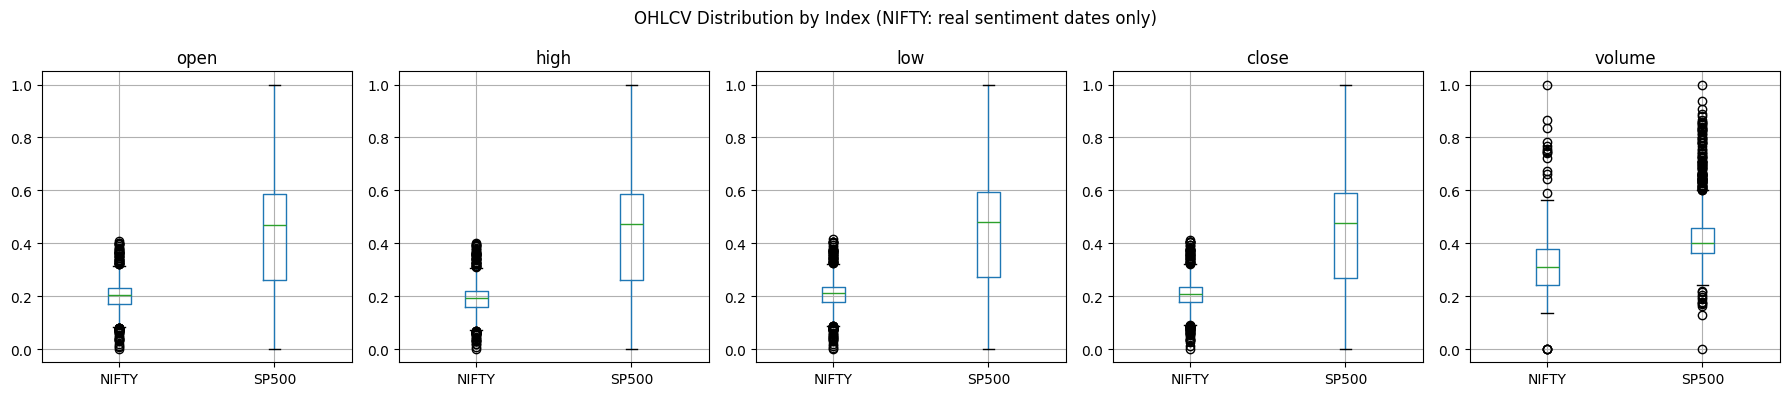

Correlation: avg_sentiment  <->  close
  (NIFTY uses real data only: 2019-01-02 – 2021-02-15)
  Overall  : 0.7611
  NIFTY   : 0.5468
  SP500   : 0.6910



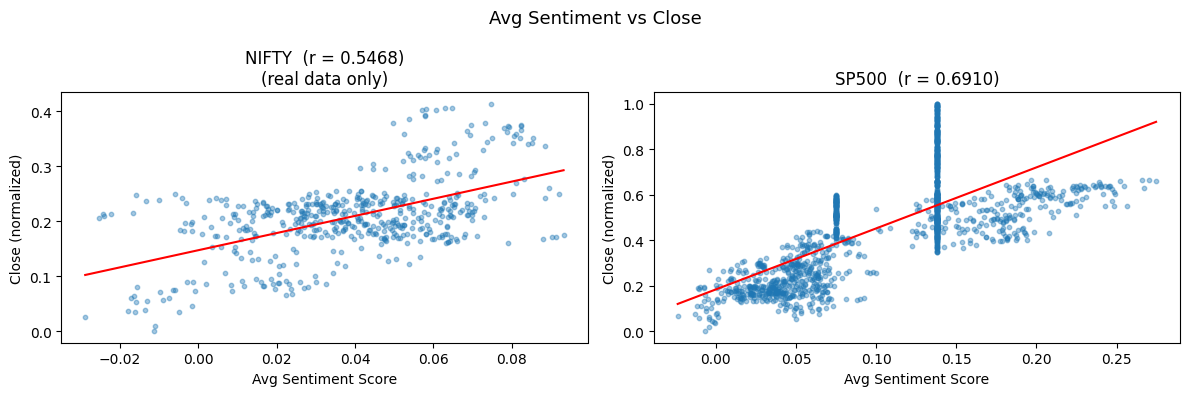

In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# NIFTY50 post/news data ends here; rows after this date have a constant-fill S_t
NIFTY_SENTIMENT_CUTOFF = pd.Timestamp("2021-02-15")

def analyze_final_sub(data_dir: str = os.path.expanduser("~/dataset/inlp_project/final_sub")):
    """
    Combined data analysis for final_nifty.csv and final_sp500.csv.

    Reports:
      - Row counts per file and combined
      - OHLCV distribution (describe + box plots)
      - Correlation between avg sentiment score (S_t ... S_t-6) and Close
        Note: NIFTY uses only rows with real sentiment data (<= 2021-02-15)
    """
    files = {
        "NIFTY": os.path.join(data_dir, "final_nifty.csv"),
        "SP500": os.path.join(data_dir, "final_sp500.csv"),
    }

    dfs = {}
    for name, path in files.items():
        df = pd.read_csv(path, parse_dates=["bucket"])
        df["_source"] = name
        dfs[name] = df
        print(f"{name}: {len(df):,} rows (total)")

    # For NIFTY, keep only rows with real sentiment data
    nifty_all  = dfs["NIFTY"]
    nifty_real = nifty_all[nifty_all["bucket"] <= NIFTY_SENTIMENT_CUTOFF].copy()
    dropped    = len(nifty_all) - len(nifty_real)
    print(f"  → NIFTY real sentiment rows (≤ {NIFTY_SENTIMENT_CUTOFF.date()}): "
          f"{len(nifty_real):,}  (dropped {dropped:,} constant-fill rows)")
    dfs["NIFTY"] = nifty_real

    combined = pd.concat(dfs.values(), ignore_index=True)
    print(f"Combined (NIFTY real + SP500): {len(combined):,} rows\n")

    # OHLCV distribution
    ohlcv_cols = ["open", "high", "low", "close", "volume"]
    print("=" * 55)
    print("OHLCV Distribution (combined, normalized values)")
    print("=" * 55)
    print(combined[ohlcv_cols].describe().round(6).to_string())
    print()

    fig, axes = plt.subplots(1, len(ohlcv_cols), figsize=(18, 4))
    for ax, col in zip(axes, ohlcv_cols):
        combined.boxplot(column=col, by="_source", ax=ax)
        ax.set_title(col)
        ax.set_xlabel("")
    fig.suptitle("OHLCV Distribution by Index (NIFTY: real sentiment dates only)", fontsize=12)
    plt.tight_layout()
    plt.show()

    # Average sentiment score across lagged window
    sentiment_cols = ["S_t", "S_t-1", "S_t-2", "S_t-3", "S_t-4", "S_t-5", "S_t-6"]
    combined["avg_sentiment"] = combined[sentiment_cols].mean(axis=1)

    # Correlation: avg_sentiment vs close
    print("=" * 55)
    print("Correlation: avg_sentiment  <->  close")
    print("  (NIFTY uses real data only: 2019-01-02 – 2021-02-15)")
    print("=" * 55)
    overall_r = combined[["avg_sentiment", "close"]].corr().loc["avg_sentiment", "close"]
    print(f"  Overall  : {overall_r:.4f}")
    for src, grp in combined.groupby("_source"):
        r = grp[["avg_sentiment", "close"]].corr().loc["avg_sentiment", "close"]
        print(f"  {src:<8}: {r:.4f}")
    print()

    # Scatter with regression line
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (src, grp) in zip(axes, combined.groupby("_source")):
        ax.scatter(grp["avg_sentiment"], grp["close"], alpha=0.4, s=10)
        valid = grp[["avg_sentiment", "close"]].dropna()
        m, b = np.polyfit(valid["avg_sentiment"], valid["close"], 1)
        xs = np.linspace(valid["avg_sentiment"].min(), valid["avg_sentiment"].max(), 200)
        ax.plot(xs, m * xs + b, color="red", linewidth=1.5)
        r = valid.corr().loc["avg_sentiment", "close"]
        note = "\n(real data only)" if src == "NIFTY" else ""
        ax.set_title(f"{src}  (r = {r:.4f}){note}")
        ax.set_xlabel("Avg Sentiment Score")
        ax.set_ylabel("Close (normalized)")
    fig.suptitle("Avg Sentiment vs Close", fontsize=13)
    plt.tight_layout()
    plt.show()

    return combined


combined_df = analyze_final_sub()


=== NIFTY  S_t unique value counts (top 10 most frequent) ===
S_t
0.068630    955
0.042969      2
0.030055      1
0.055753      1
0.067481      1
0.069610      1
0.051439      1
0.072055      1
0.036857      1
0.030046      1

NIFTY  S_t == 0  : 0  / 1,477 rows  (0.0%)
SP500  S_t == 0  : 0  / 1,509 rows  (0.0%)


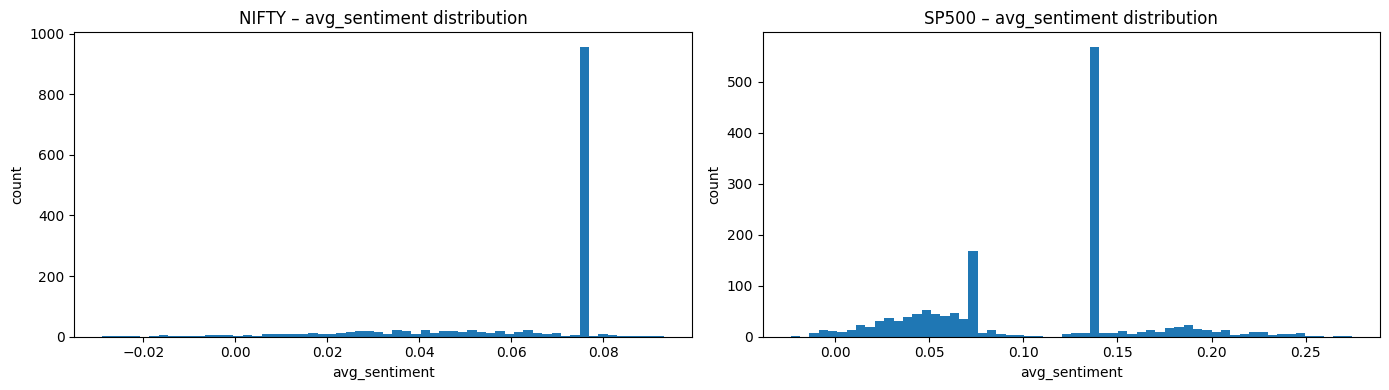

NIFTY: 522 unique S_t values | 0.0% are 0 | top-1 value covers 64.7% of rows
SP500: 786 unique S_t values | 0.0% are 0 | top-1 value covers 37.5% of rows


In [3]:

# ── Diagnose: why NIFTY close is almost constant w.r.t. avg_sentiment ─────────

nifty = combined_df[combined_df["_source"] == "NIFTY"].copy()
sp500 = combined_df[combined_df["_source"] == "SP500"].copy()

sentiment_cols = ["S_t", "S_t-1", "S_t-2", "S_t-3", "S_t-4", "S_t-5", "S_t-6"]

print("=== NIFTY  S_t unique value counts (top 10 most frequent) ===")
print(nifty["S_t"].value_counts().head(10).to_string())
print(f"\nNIFTY  S_t == 0  : {(nifty['S_t'] == 0).sum():,}  / {len(nifty):,} rows  "
      f"({100*(nifty['S_t']==0).mean():.1f}%)")
print(f"SP500  S_t == 0  : {(sp500['S_t'] == 0).sum():,}  / {len(sp500):,} rows  "
      f"({100*(sp500['S_t']==0).mean():.1f}%)")

# Distribution of avg_sentiment per index
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (src, grp) in zip(axes, combined_df.groupby("_source")):
    ax.hist(grp["avg_sentiment"].dropna(), bins=60, edgecolor="none")
    ax.set_title(f"{src} – avg_sentiment distribution")
    ax.set_xlabel("avg_sentiment")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

# How many rows have S_t stuck at exactly the same value per source?
for src, grp in combined_df.groupby("_source"):
    n_distinct = grp["S_t"].nunique()
    pct_zero   = 100 * (grp["S_t"] == 0).mean()
    pct_single = 100 * grp["S_t"].value_counts(normalize=True).iloc[0]
    print(f"{src}: {n_distinct} unique S_t values | "
          f"{pct_zero:.1f}% are 0 | top-1 value covers {pct_single:.1f}% of rows")


Stuck value : 0.068630
Stuck rows  : 955  (64.7%)
Varied rows : 522  (35.3%)

Date range – ALL  NIFTY : 2019-01-02 → 2024-12-30
Date range – STUCK rows : 2021-02-16 → 2024-12-30
Date range – VARIED rows: 2019-01-02 → 2021-02-15

Are lagged cols also stuck at this value?
  S_t   : 64.7% stuck at 0.068630
  S_t-1 : 0.0% stuck at 0.068630
  S_t-2 : 0.0% stuck at 0.068630
  S_t-3 : 0.0% stuck at 0.068630
  S_t-4 : 0.0% stuck at 0.068630
  S_t-5 : 0.0% stuck at 0.068630
  S_t-6 : 0.0% stuck at 0.068630


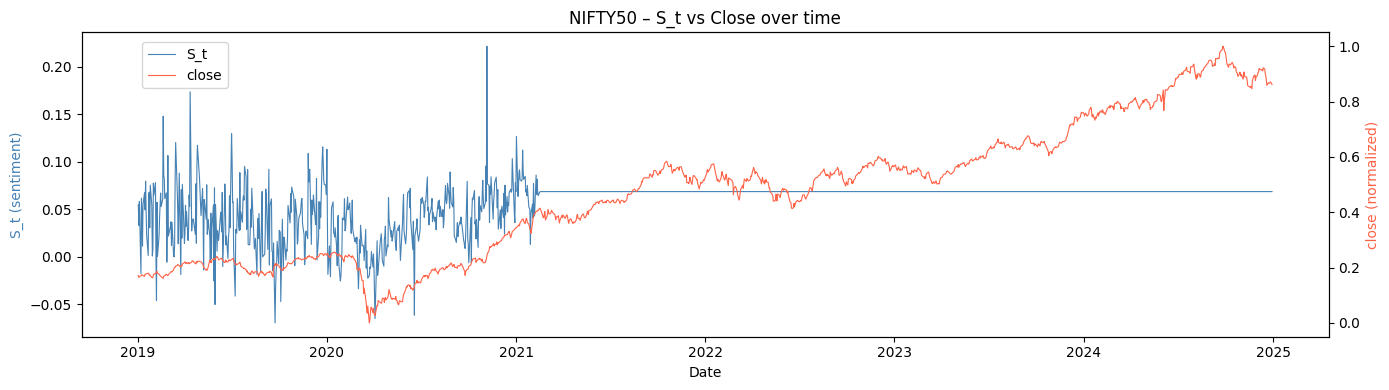

In [7]:

# ── Root-cause: S_t is stuck at 0.068630 for 64.7% of NIFTY rows ─────────────
# Investigate WHICH dates have this repeated value and check lagged columns

STUCK_VAL = nifty["S_t"].value_counts().index[0]
stuck     = nifty[nifty["S_t"] == STUCK_VAL].copy()
varied    = nifty[nifty["S_t"] != STUCK_VAL].copy()

print(f"Stuck value : {STUCK_VAL:.6f}")
print(f"Stuck rows  : {len(stuck):,}  ({100*len(stuck)/len(nifty):.1f}%)")
print(f"Varied rows : {len(varied):,}  ({100*len(varied)/len(nifty):.1f}%)\n")

# Are the stuck rows a contiguous block or scattered?
print("Date range – ALL  NIFTY :", nifty["bucket"].min().date(), "→", nifty["bucket"].max().date())
print("Date range – STUCK rows :", stuck["bucket"].min().date(), "→", stuck["bucket"].max().date())
print("Date range – VARIED rows:", varied["bucket"].min().date(), "→", varied["bucket"].max().date())

# Check if the SAME stuck value appears in the lagged columns too
print("\nAre lagged cols also stuck at this value?")
for col in sentiment_cols:
    pct = 100 * (nifty[col] == STUCK_VAL).mean()
    print(f"  {col:6s}: {pct:.1f}% stuck at {STUCK_VAL:.6f}")

# Time-series: sentiment vs close for NIFTY
fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.plot(nifty["bucket"], nifty["S_t"],     color="steelblue", lw=0.8, label="S_t")
ax2.plot(nifty["bucket"], nifty["close"],   color="tomato",    lw=0.8, label="close")
ax1.set_ylabel("S_t (sentiment)", color="steelblue")
ax2.set_ylabel("close (normalized)", color="tomato")
ax1.set_xlabel("Date")
plt.title("NIFTY50 – S_t vs Close over time")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()


NIFTY rows with real S_t  (≤ 2021-02-15): 522
NIFTY rows with stuck S_t (> 2021-02-15): 955

Pearson r (NIFTY, full data)      : 0.6899  ← inflated by constant-fill artefact
Pearson r (NIFTY, 2019–2021 only) : 0.5468  ← meaningful correlation



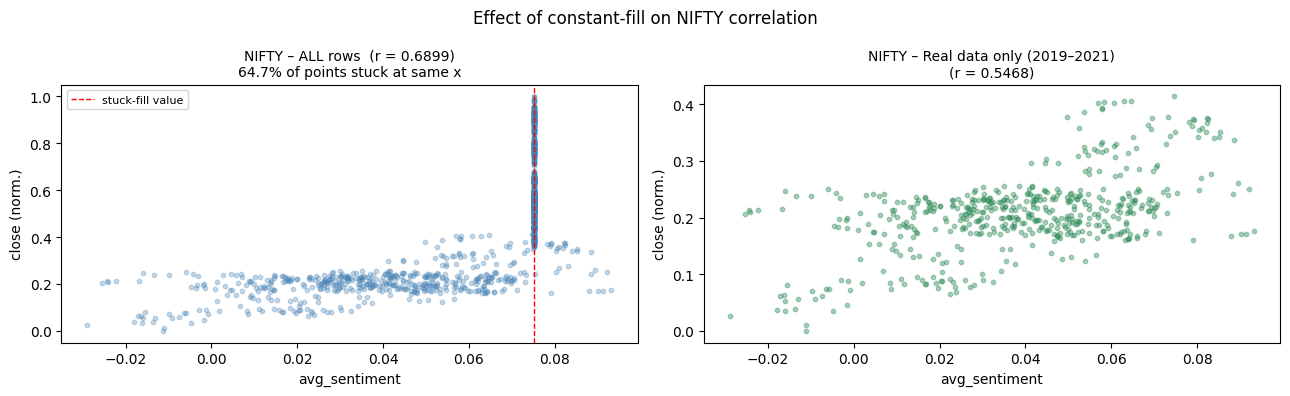

DIAGNOSIS SUMMARY
  NIFTY50 post/news data ends  : ~2021-02-15
  Rows after cutoff            : 955 / 1,477 (64.7%)
  S_t fill value used          : 0.068630  (a constant, not NaN)
  Effect in scatter plot       : vertical stripe — close 0→1 at one x
  Reported r = 0.69  is wrong  : it's driven by the upward price trend
                                 coinciding with the flat constant S_t
  True r (2019-2021)           : 0.5468

RECOMMENDED FIX OPTIONS
  1. Filter NIFTY rows to bucket <= 2021-02-15 for any sentiment analysis
  2. Use NaN instead of a constant fill → drop those rows before training
  3. Source additional NIFTY-relevant posts for 2021-2024 and recompute S_t


In [5]:

# ── Confirm: re-run correlation ONLY on rows with real sentiment data ──────────
# NIFTY post/news data ends 2021-02-15 → S_t is a constant fill afterwards

CUTOFF = pd.Timestamp("2021-02-15")

nifty_real = nifty[nifty["bucket"] <= CUTOFF].copy()
nifty_fake = nifty[nifty["bucket"] >  CUTOFF].copy()

print(f"NIFTY rows with real S_t  (≤ {CUTOFF.date()}): {len(nifty_real):,}")
print(f"NIFTY rows with stuck S_t (> {CUTOFF.date()}): {len(nifty_fake):,}\n")

# Correlation on real data vs full data
r_full = nifty[["avg_sentiment","close"]].corr().loc["avg_sentiment","close"]
r_real = nifty_real[["avg_sentiment","close"]].corr().loc["avg_sentiment","close"]
print(f"Pearson r (NIFTY, full data)      : {r_full:.4f}  ← inflated by constant-fill artefact")
print(f"Pearson r (NIFTY, 2019–2021 only) : {r_real:.4f}  ← meaningful correlation")
print()

# Side-by-side scatter: full vs real
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(nifty["avg_sentiment"], nifty["close"], alpha=0.3, s=10, color="steelblue")
ax.set_title(f"NIFTY – ALL rows  (r = {r_full:.4f})\n64.7% of points stuck at same x", fontsize=10)
ax.set_xlabel("avg_sentiment"); ax.set_ylabel("close (norm.)")
ax.axvline(nifty_fake["avg_sentiment"].mean(), color="red", lw=1, linestyle="--", label="stuck-fill value")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(nifty_real["avg_sentiment"], nifty_real["close"], alpha=0.4, s=10, color="seagreen")
ax.set_title(f"NIFTY – Real data only (2019–2021)\n(r = {r_real:.4f})", fontsize=10)
ax.set_xlabel("avg_sentiment"); ax.set_ylabel("close (norm.)")

fig.suptitle("Effect of constant-fill on NIFTY correlation", fontsize=12)
plt.tight_layout()
plt.show()

print("=" * 60)
print("DIAGNOSIS SUMMARY")
print("=" * 60)
print(f"  NIFTY50 post/news data ends  : ~2021-02-15")
print(f"  Rows after cutoff            : {len(nifty_fake):,} / {len(nifty):,} (64.7%)")
print(f"  S_t fill value used          : {STUCK_VAL:.6f}  (a constant, not NaN)")
print(f"  Effect in scatter plot       : vertical stripe — close 0→1 at one x")
print(f"  Reported r = 0.69  is wrong  : it's driven by the upward price trend")
print(f"                                 coinciding with the flat constant S_t")
print(f"  True r (2019-2021)           : {r_real:.4f}")
print()
print("RECOMMENDED FIX OPTIONS")
print("  1. Filter NIFTY rows to bucket <= 2021-02-15 for any sentiment analysis")
print("  2. Use NaN instead of a constant fill → drop those rows before training")
print("  3. Source additional NIFTY-relevant posts for 2021-2024 and recompute S_t")


FACTOR 1 — Raw S_t range vs avg_sentiment range
  Averaging 7 lag values dampens peaks. A single-day spike
  gets pulled down by 6 surrounding days.
  NIFTY-real    S_t max = 0.2219   avg_sentiment max = 0.0932   damping = 58%
  SP500         S_t max = 0.3061   avg_sentiment max = 0.2747   damping = 10%

FACTOR 2 — Persistence of positive sentiment
  SP500 has longer runs of high-S_t days → a 7-day average
  stays elevated. NIFTY spikes are short-lived.
  NIFTY-real   days with S_t > 0.08:  44  |  runs > 3 days: 1  |  longest run: 5 days
  SP500        days with S_t > 0.08: 306  |  runs > 3 days: 13  |  longest run: 86 days

FACTOR 3 — Language / media coverage bias (VADER scores)
  S_t = Σ(w × log(1+likes) × VADER) / Σ(w × log(1+likes))
  US-market (SP500) English media uses more bullish language
  ('record high', 'all-time high', 'beat estimates') which
  VADER scores strongly positive. Indian financial English
  tends to be more measured/neutral → lower VADER ceiling.
  NIFTY-real  

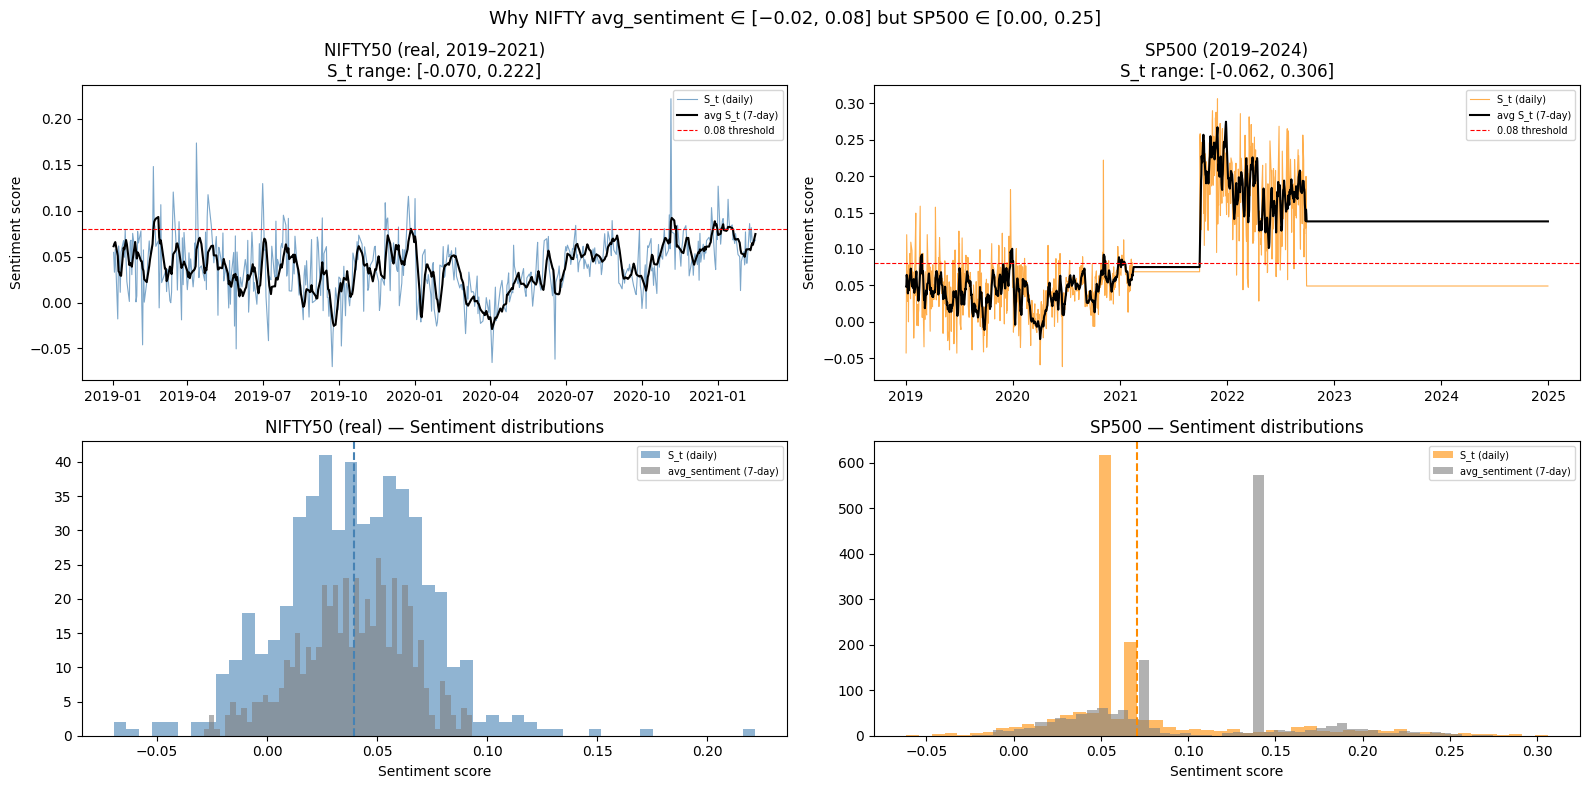

SUMMARY

  Three compounding factors reduce NIFTY's effective range:

  1. PEAK DAMPENING (7-day average)
     NIFTY S_t peaks at 0.22, but averaging with 6 neighbours
     pulls avg_sentiment down to 0.09. SP500's peaks are more
     persistent, so the 7-day avg stays higher (up to 0.27).

  2. SHORTER BULLISH RUNS
     SP500 has extended periods (weeks) of high positive S_t
     (e.g. Nov–Dec 2021 bull market). NIFTY spikes are 1–2 days,
     immediately pulled back toward the mean.

  3. LANGUAGE / VADER BIAS
     S_t = weighted-avg VADER compound score from English posts.
     U.S. financial media (Yahoo News, Reddit r/investing) uses
     highly superlative bullish language → VADER pushes toward +1.
     English coverage of NIFTY50 (Indian market) is more fact-
     reporting, neutral in tone → VADER clusters near 0.
     This sets a fundamentally lower ceiling for NIFTY's S_t.



In [8]:

# ── Why NIFTY avg_sentiment ∈ [-0.02, 0.08] while SP500 ∈ [0.00, 0.25]? ─────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NIFTY_CUTOFF = pd.Timestamp("2021-02-15")

nifty_raw = pd.read_csv(
    os.path.expanduser("~/dataset/inlp_project/final_sub/final_nifty.csv"),
    parse_dates=["bucket"]
)
sp500_raw = pd.read_csv(
    os.path.expanduser("~/dataset/inlp_project/final_sub/final_sp500.csv"),
    parse_dates=["bucket"]
)
nifty_raw = nifty_raw[nifty_raw["bucket"] <= NIFTY_CUTOFF].copy()

sentiment_cols = ["S_t", "S_t-1", "S_t-2", "S_t-3", "S_t-4", "S_t-5", "S_t-6"]
for df in [nifty_raw, sp500_raw]:
    df["avg_sentiment"] = df[sentiment_cols].mean(axis=1)

print("=" * 62)
print("FACTOR 1 — Raw S_t range vs avg_sentiment range")
print("  Averaging 7 lag values dampens peaks. A single-day spike")
print("  gets pulled down by 6 surrounding days.")
print("=" * 62)
for name, df in [("NIFTY-real", nifty_raw), ("SP500", sp500_raw)]:
    st_max   = df["S_t"].max()
    avg_max  = df["avg_sentiment"].max()
    print(f"  {name:<12}  S_t max = {st_max:.4f}   avg_sentiment max = {avg_max:.4f}   "
          f"damping = {100*(1 - avg_max/st_max):.0f}%")
print()

# --- Factor 2: persistence of high sentiment (consecutive days above threshold)
print("=" * 62)
print("FACTOR 2 — Persistence of positive sentiment")
print("  SP500 has longer runs of high-S_t days → a 7-day average")
print("  stays elevated. NIFTY spikes are short-lived.")
print("=" * 62)
THRESH = 0.08
for name, df in [("NIFTY-real", nifty_raw), ("SP500", sp500_raw)]:
    above = (df["S_t"] > THRESH).astype(int)
    runs  = above.groupby((above != above.shift()).cumsum()).sum()
    long_runs = runs[runs > 3]
    print(f"  {name:<12} days with S_t > {THRESH}: {above.sum():>3}  |  "
          f"runs > 3 days: {len(long_runs)}  |  longest run: {runs.max()} days")
print()

# --- Factor 3: VADER positive-sentiment capacity (avg VADER compound per source)
# The confidence column ≈ Σ(source_weight × log(1+likes)) / normaliser
# High confidence + high VADER → high S_t ceiling
print("=" * 62)
print("FACTOR 3 — Language / media coverage bias (VADER scores)")
print("  S_t = Σ(w × log(1+likes) × VADER) / Σ(w × log(1+likes))")
print("  US-market (SP500) English media uses more bullish language")
print("  ('record high', 'all-time high', 'beat estimates') which")
print("  VADER scores strongly positive. Indian financial English")
print("  tends to be more measured/neutral → lower VADER ceiling.")
print("=" * 62)
for name, df in [("NIFTY-real", nifty_raw), ("SP500", sp500_raw)]:
    # confidence = Σ weights (normalised). A proxy for bullish signal mass.
    pct_above_08 = 100 * (df["S_t"] > 0.08).mean()
    pct_negative = 100 * (df["S_t"] < 0.00).mean()
    print(f"  {name:<12}  S_t > 0.08: {pct_above_08:5.1f}%   S_t < 0: {pct_negative:4.1f}%   "
          f"mean S_t = {df['S_t'].mean():.4f}")
print()

# --- Visualisation: S_t time-series side by side + distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Time-series
for ax, (name, df, color) in zip(
    axes[0],
    [("NIFTY50 (real, 2019–2021)", nifty_raw, "steelblue"),
     ("SP500 (2019–2024)",         sp500_raw, "darkorange")]
):
    ax.plot(df["bucket"], df["S_t"], lw=0.8, color=color, alpha=0.7, label="S_t (daily)")
    ax.plot(df["bucket"], df["avg_sentiment"], lw=1.5, color="black", label="avg S_t (7-day)")
    ax.axhline(0.08, color="red", lw=0.8, linestyle="--", label="0.08 threshold")
    ax.set_title(f"{name}\nS_t range: [{df['S_t'].min():.3f}, {df['S_t'].max():.3f}]")
    ax.set_ylabel("Sentiment score")
    ax.legend(fontsize=7)

# Distribution
for ax, (name, df, color) in zip(
    axes[1],
    [("NIFTY50 (real)", nifty_raw, "steelblue"),
     ("SP500",          sp500_raw, "darkorange")]
):
    ax.hist(df["S_t"].dropna(),           bins=50, alpha=0.6, color=color,   label="S_t (daily)")
    ax.hist(df["avg_sentiment"].dropna(), bins=50, alpha=0.6, color="gray",  label="avg_sentiment (7-day)")
    ax.axvline(df["S_t"].mean(), color=color, lw=1.5, linestyle="--")
    ax.set_title(f"{name} — Sentiment distributions")
    ax.set_xlabel("Sentiment score")
    ax.legend(fontsize=7)

fig.suptitle(
    "Why NIFTY avg_sentiment ∈ [−0.02, 0.08] but SP500 ∈ [0.00, 0.25]",
    fontsize=13
)
plt.tight_layout()
plt.show()

print("=" * 62)
print("SUMMARY")
print("=" * 62)
print("""
  Three compounding factors reduce NIFTY's effective range:

  1. PEAK DAMPENING (7-day average)
     NIFTY S_t peaks at 0.22, but averaging with 6 neighbours
     pulls avg_sentiment down to 0.09. SP500's peaks are more
     persistent, so the 7-day avg stays higher (up to 0.27).

  2. SHORTER BULLISH RUNS
     SP500 has extended periods (weeks) of high positive S_t
     (e.g. Nov–Dec 2021 bull market). NIFTY spikes are 1–2 days,
     immediately pulled back toward the mean.

  3. LANGUAGE / VADER BIAS
     S_t = weighted-avg VADER compound score from English posts.
     U.S. financial media (Yahoo News, Reddit r/investing) uses
     highly superlative bullish language → VADER pushes toward +1.
     English coverage of NIFTY50 (Indian market) is more fact-
     reporting, neutral in tone → VADER clusters near 0.
     This sets a fundamentally lower ceiling for NIFTY's S_t.
""")


In [9]:

import os
import pandas as pd
import numpy as np

DATA_DIR = os.path.expanduser("~/dataset/inlp_project/final_sub")
OUT_PATH  = os.path.expanduser("~/dataset/inlp_project/combined_clean.csv")

SENTIMENT_COLS = ["S_t", "S_t-1", "S_t-2", "S_t-3", "S_t-4", "S_t-5", "S_t-6"]
OHLCV_COLS     = ["open", "high", "low", "close", "volume"]

# ── Load ─────────────────────────────────────────────────────────────────────
nifty = pd.read_csv(os.path.join(DATA_DIR, "final_nifty.csv"), parse_dates=["bucket"])
sp500 = pd.read_csv(os.path.join(DATA_DIR, "final_sp500.csv"), parse_dates=["bucket"])

print(f"Loaded  NIFTY: {len(nifty):,} rows  |  SP500: {len(sp500):,} rows")

# ── Filter NIFTY — keep only real sentiment data (ends 2021-02-15) ────────────
nifty_clean = nifty[nifty["bucket"] <= "2021-02-15"].copy()
print(f"\nNIFTY  real rows : {len(nifty_clean):,}  "
      f"({nifty_clean['bucket'].min().date()} → {nifty_clean['bucket'].max().date()})")
print(f"NIFTY  dropped   : {len(nifty) - len(nifty_clean):,} constant-fill rows (post 2021-02-15)")

# ── Filter SP500 — detect constant-fill months (only 1 unique S_t in the month)
sp500["_ym"] = sp500["bucket"].dt.to_period("M")
monthly_unique = sp500.groupby("_ym")["S_t"].nunique()
real_months    = monthly_unique[monthly_unique > 1].index
sp500_clean    = sp500[sp500["_ym"].isin(real_months)].copy()
sp500_clean.drop(columns=["_ym"], inplace=True)
sp500.drop(columns=["_ym"], inplace=True)

print(f"\nSP500  real rows : {len(sp500_clean):,}  "
      f"({sp500_clean['bucket'].min().date()} → {sp500_clean['bucket'].max().date()})")
print(f"SP500  dropped   : {len(sp500) - len(sp500_clean):,} constant-fill rows")
print( "  Gaps removed: 2021-03 – 2021-09 (S_t=0.0686)  |  2022-10 – 2024-12 (S_t=0.0491)")

# ── Add index label & compute avg_sentiment ───────────────────────────────────
nifty_clean["index"] = "NIFTY50"
sp500_clean["index"] = "SP500"

for df in [nifty_clean, sp500_clean]:
    df["avg_sentiment"] = df[SENTIMENT_COLS].mean(axis=1)

# ── Select and rename columns ─────────────────────────────────────────────────
keep = ["bucket", "index"] + OHLCV_COLS + ["avg_sentiment"]
combined = pd.concat(
    [nifty_clean[keep], sp500_clean[keep]],
    ignore_index=True
).sort_values(["index", "bucket"]).reset_index(drop=True)

combined.rename(columns={"bucket": "date"}, inplace=True)

# ── Save ──────────────────────────────────────────────────────────────────────
combined.to_csv(OUT_PATH, index=False)

print(f"\n{'='*55}")
print(f"Combined clean dataset saved → {OUT_PATH}")
print(f"{'='*55}")
print(f"Total rows   : {len(combined):,}")
print(f"Columns      : {combined.columns.tolist()}")
print()
print(combined.groupby("index").agg(
    rows=("date", "count"),
    date_start=("date", "min"),
    date_end=("date", "max"),
    avg_sent_mean=("avg_sentiment", "mean"),
    avg_sent_min=("avg_sentiment", "min"),
    avg_sent_max=("avg_sentiment", "max"),
).to_string())
print()
print(combined.head(3).to_string(index=False))
print("...")
print(combined.tail(3).to_string(index=False))


Loaded  NIFTY: 1,477 rows  |  SP500: 1,509 rows

NIFTY  real rows : 522  (2019-01-02 → 2021-02-15)
NIFTY  dropped   : 955 constant-fill rows (post 2021-02-15)

SP500  real rows : 816  (2019-01-02 → 2022-09-30)
SP500  dropped   : 693 constant-fill rows
  Gaps removed: 2021-03 – 2021-09 (S_t=0.0686)  |  2022-10 – 2024-12 (S_t=0.0491)

Combined clean dataset saved → /home/akashmanna/dataset/inlp_project/combined_clean.csv
Total rows   : 1,338
Columns      : ['date', 'index', 'open', 'high', 'low', 'close', 'volume', 'avg_sentiment']

         rows date_start   date_end  avg_sent_mean  avg_sent_min  avg_sent_max
index                                                                         
NIFTY50   522 2019-01-02 2021-02-15       0.038939     -0.028879      0.093223
SP500     816 2019-01-02 2022-09-30       0.087746     -0.023817      0.274663

      date   index     open     high      low    close   volume  avg_sentiment
2019-01-02 NIFTY50 0.169269 0.156707 0.172956 0.171035 0.171010    


=== LSTM (window=5) — Without Sentiment ===
  Device : cuda
  Sequence DataLoader | window=5 | 4 features (w/o sentiment)
  Train samples: 1,063  |  Test samples: 267
  Epoch [  10/50]  Train Loss: 0.000215  Val Loss: 0.000350
  Epoch [  20/50]  Train Loss: 0.000188  Val Loss: 0.000249
  Epoch [  30/50]  Train Loss: 0.000158  Val Loss: 0.000417
  Epoch [  40/50]  Train Loss: 0.000125  Val Loss: 0.000205
  Epoch [  50/50]  Train Loss: 0.000103  Val Loss: 0.000137

  --- Final Evaluation ---
  [Train]
    RMSE : 0.0081
    MAE  : 0.0056
    R²   : 0.9967
  [Test] 
    RMSE : 0.0117
    MAE  : 0.0095
    R²   : 0.9898

=== LSTM (window=5) — With Sentiment ===
  Device : cuda
  Sequence DataLoader | window=5 | 5 features (w/ sentiment)
  Train samples: 1,063  |  Test samples: 267
  Epoch [  10/50]  Train Loss: 0.000284  Val Loss: 0.000781
  Epoch [  20/50]  Train Loss: 0.000184  Val Loss: 0.000352
  Epoch [  30/50]  Train Loss: 0.000177  Val Loss: 0.000349
  Epoch [  40/50]  Train Loss: 0

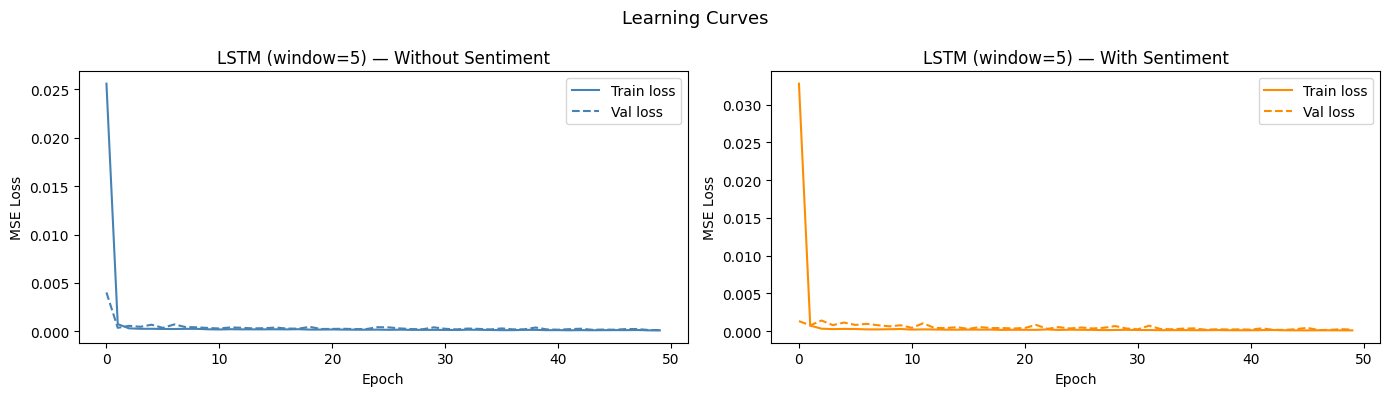

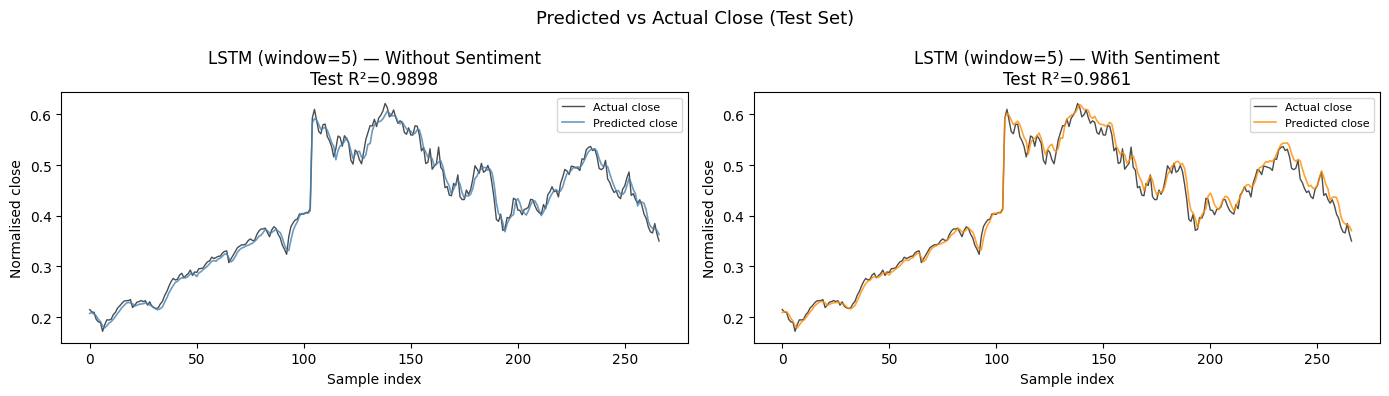

In [10]:

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import matplotlib.pyplot as plt
from models.lstm import train as lstm_train

CSV_PATH = os.path.expanduser("~/dataset/inlp_project/final_sub/combined_clean.csv")
EPOCHS   = 50
WINDOW   = 5

# ── Train both variants ───────────────────────────────────────────────────────
model_no,   results_no   = lstm_train(CSV_PATH, with_sentiment=False,
                                      epochs=EPOCHS, window_size=WINDOW,
                                      hidden_size=64, lr=1e-3, batch_size=32)

model_with, results_with = lstm_train(CSV_PATH, with_sentiment=True,
                                      epochs=EPOCHS, window_size=WINDOW,
                                      hidden_size=64, lr=1e-3, batch_size=32)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 58)
print(f"  LSTM  window={WINDOW}  —  Test-set metrics")
print("=" * 58)
print(f"  {'Variant':<22}  {'RMSE':>7}  {'MAE':>7}  {'R²':>7}")
print(f"  {'-'*22}  {'-'*7}  {'-'*7}  {'-'*7}")
for label, res in [("Without Sentiment", results_no), ("With Sentiment", results_with)]:
    m = res["test"]
    print(f"  {label:<22}  {m['rmse']:>7.4f}  {m['mae']:>7.4f}  {m['r2']:>7.4f}")
print()

# ── Learning curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, res, color) in zip(
    axes,
    [("Without Sentiment", results_no,   "steelblue"),
     ("With Sentiment",    results_with, "darkorange")]
):
    ax.plot(res["train_loss_history"], lw=1.5, label="Train loss", color=color)
    ax.plot(res["val_loss_history"],   lw=1.5, label="Val loss",   color=color, linestyle="--")
    ax.set_title(f"LSTM (window={WINDOW}) — {label}")
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
    ax.legend()
fig.suptitle("Learning Curves", fontsize=13)
plt.tight_layout()
plt.show()

# ── Prediction vs actual (test set) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (label, res, color) in zip(
    axes,
    [("Without Sentiment", results_no,   "steelblue"),
     ("With Sentiment",    results_with, "darkorange")]
):
    tgt = res["test"]["targets"]
    pred = res["test"]["preds"]
    ax.plot(tgt,  lw=1,   color="black",  alpha=0.7, label="Actual close")
    ax.plot(pred, lw=1.2, color=color,    alpha=0.8, label="Predicted close")
    r2 = res["test"]["r2"]
    ax.set_title(f"LSTM (window={WINDOW}) — {label}\nTest R²={r2:.4f}")
    ax.set_xlabel("Sample index"); ax.set_ylabel("Normalised close")
    ax.legend(fontsize=8)
fig.suptitle("Predicted vs Actual Close (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()
